In [1]:
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR
)

DATA_DIR = 'examples/gw_grip_home/data_dir'
# DATA_DIR = 'examples/bw_grip_home/data_dir'
seeds = os.listdir(os.path.join(DATA_DIR, PROCESSED_DIR))
# seeds = []

all_renders = {}
gts = {}
preds = {seed: {} for seed in seeds}
for renders_file in tqdm(glob.glob(os.path.join(DATA_DIR, RENDERS_DIR, '*.npz'))):
    dp_name = os.path.splitext(os.path.basename(renders_file))[0]
    
    all_renders[dp_name] = np.load(renders_file)

    try:
        with open(os.path.join(DATA_DIR, TRUE_STATES_DIR, dp_name + '.json'), 'r') as f:
            gts[dp_name] = json.load(f)
    except FileNotFoundError:
        pass

    for seed in seeds:
        try:
            with open(os.path.join(DATA_DIR, PROCESSED_DIR, str(seed), dp_name + '.json'), 'r') as f:
                preds[seed][dp_name] = json.load(f)
        except FileNotFoundError:
            pass

# display how many datapoints were processed by each config
{k: len(v) for k, v in preds.items()}

  0%|          | 0/2000 [00:00<?, ?it/s]

{'llama-llava-iter-images-with-milk-inst-72B': 1675,
 'llama-llava-iter-images-72B': 1680,
 'llama-llava-iter-images': 2000,
 'default-llama-llava': 2000,
 'llama-llava-iter-images-with-milk-inst': 2000}

In [3]:
discovered_states = {}
for fname in tqdm(glob.glob('stam/*.json')):
    with open(fname, 'r') as f:
        discovered_states[fname] = json.load(f)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [4]:
import pandas as pd
df = pd.DataFrame.from_dict(discovered_states).T
df.head()

,robot-gripping(lemon),robot-gripper-empty(),"on-table(lemon,white-table)",robot-gripping(green-bottle),"on-table(green-bottle,black-table)",robot-gripping(loaf-of-bread),"on-table(loaf-of-bread,white-table)","on-table(loaf-of-bread,wood-table)","on-table(lemon,wood-table)",robot-gripping(red-box-of-cereal),...,"on-table(loaf-of-bread,black-table)","on-table(red-can-of-soda,black-table)",robot-gripping(milk-carton),"on-table(milk-carton,black-table)","on-table(milk-carton,wood-table)","on-table(red-box-of-cereal,black-table)","on-table(green-bottle,wood-table)","on-table(milk-carton,white-table)","on-table(green-bottle,white-table)","on-table(red-box-of-cereal,white-table)"
stam/state_003788.json,False,True,True,False,True,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
stam/state_004445.json,False,False,True,False,False,False,True,False,False,True,...,False,False,False,False,True,False,True,False,False,False
stam/state_006868.json,False,True,False,False,False,False,False,True,True,False,...,False,True,False,False,True,False,True,False,False,False
stam/state_004839.json,False,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,True,False,True,True,False
stam/state_006414.json,False,True,False,False,True,False,False,False,False,False,...,True,False,False,True,False,True,False,False,False,False


In [5]:
df.drop_duplicates(inplace=True)
df = df.reindex(sorted(df.columns), axis=1)

In [6]:
cooc_mat = df.T @ df

In [ ]:
cooc_mat = (df.astype(float).T @ df.astype(float)) / len(df)

In [7]:
cooc_mat = cooc_mat.to_numpy()

In [8]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score
)
import numpy as np
from itertools import combinations


def squash_predicate(dp_dicts):
    out = []
    dp_dict_keys_sorted = sorted(dp_dicts.keys())
    predicates = sorted(next(iter(dp_dicts.values())))
    for dp_key in dp_dict_keys_sorted:
        dp_arr = []
        for predicate in predicates:
            dp_arr.append(dp_dicts[dp_key][predicate])
        out.append(dp_arr)

    return np.array(out)

def npv_spcificity_curve(y, y_score, thresholds):
    npv = []
    specificity = []
    for t in thresholds:
        tn, fp, fn, tp = confusion_matrix(y, y_score > t).ravel()
        npv.append(tn / (tn + fn))
        specificity.append(tn / (tn + fp))

    return np.array(npv), np.array(specificity)

def get_cooc_pred(ground_truths, predicted_scores, acc_conf, cooc_mat):
    y = squash_predicate({k: v for k, v in ground_truths.items() if k in predicted_scores})
    y_score = squash_predicate(predicted_scores)

    y_pred = y_score > acc_conf
    for j, k in combinations(range(y_pred.shape[-1]), 2):
        for dp in range(len(y_pred)):
            if y_pred[dp, j] and y_pred[dp, k] and not cooc_mat[j, k]:
                if y_score[dp, j] > y_score[dp, k]:
                    y_pred[dp, k] = False
                else:
                    y_pred[dp, j] = False

    return y_pred


def collect_metrics(ground_truths, predicted_scores, acc_conf=0.5, cooc_mat=None):
    # sqash to array format
    y = squash_predicate({k: v for k, v in ground_truths.items() if k in predicted_scores})
    y_score = squash_predicate(predicted_scores)

    if cooc_mat is not None:
        y_cooc = get_cooc_pred(ground_truths, predicted_scores, acc_conf, cooc_mat)

    # map predicates in alphabetical order for consistency
    pred_to_idx = {pred: i for i, pred in enumerate(sorted(next(iter(ground_truths.values()))))}

    # instantiate output containters
    accuracy = {}
    average_precision = {}
    precision = {}
    recall = {}
    thresholds = {}
    npv = {}
    specificity = {}
    fpr = {}
    tpr = {}
    auc = {}
    prec = {}
    rec = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {}

    # iterate predicates
    for pred, i in pred_to_idx.items():
        # get precision and recall curves
        precision[pred], recall[pred], thresholds[pred] = precision_recall_curve(y[:, i], y_score[:, i])
        thresholds[pred] = np.concatenate([thresholds[pred], [1]])  # last threshold is omitted. add it back

        # npv[pred], specificity[pred] = npv_spcificity_curve(y[:, i], y_score[:, i], thresholds[pred])

        # get ROC curve values
        fpr[pred], tpr[pred], _ = roc_curve(y[:, i], y_score[:, i])

        # get Accuracy, AP and ROC-AUC scores
        accuracy[pred] = accuracy_score(y[:, i], y_score[:, i] > acc_conf)
        prec[pred] = precision_score(y[:, i], y_score[:, i] > acc_conf)
        rec[pred] = recall_score(y[:, i], y_score[:, i] > acc_conf)
        if cooc_mat is not None:
            acc_cooc[pred] = accuracy_score(y[:, i], y_cooc[:, i])
            prec_cooc[pred] = precision_score(y[:, i], y_cooc[:, i])
            rec_cooc[pred] = recall_score(y[:, i], y_cooc[:, i])
        average_precision[pred] = average_precision_score(y[:, i], y_score[:, i])
        # auc[pred] = roc_auc_score(y[:, i], y_score[:, i])

    # get all-class AP and ROC-AUC scores
    accuracy['average'] = np.mean(list(accuracy.values()))
    acc_cooc['average'] = np.mean(list(acc_cooc.values()))
    average_precision['macro average'] = average_precision_score(y, y_score, average='macro')
    average_precision['micro average'] = average_precision_score(y, y_score, average='micro')
    # auc['macro average'] = roc_auc_score(y, y_score, average='macro')
    # auc['micro average'] = roc_auc_score(y, y_score, average='micro')

    return (
        accuracy,
        average_precision,
        precision,
        recall,
        thresholds,
        npv,
        specificity,
        fpr,
        tpr,
        auc,
        prec,
        rec,
        acc_cooc,
        prec_cooc,
        rec_cooc
    )

def collect_metrics_all_models(ground_truths, predicted_scores_all_models, acc_conf=0.5, cooc_mat=None):
    accuracy = {}
    acc_cooc = {}
    average_precision = {}
    precision = {}
    recall = {}
    thresholds = {}
    npv = {}
    specificity = {}
    fpr = {}
    tpr = {}
    auc = {}
    prec = {}
    rec = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {}
    
    for model, predicted_scores in tqdm(predicted_scores_all_models.items()):
        (
            accuracy[model],
            average_precision[model],
            precision[model],
            recall[model],
            thresholds[model],
            npv[model],
            specificity[model],
            fpr[model],
            tpr[model],
            auc[model],
            prec[model],
            rec[model],
            acc_cooc[model],
            prec_cooc[model],
            rec_cooc[model]
        ) = collect_metrics(gts, predicted_scores, acc_conf, cooc_mat)

    return (
        accuracy,
        acc_cooc,
        average_precision,
        precision,
        recall,
        thresholds,
        npv,
        specificity,
        fpr,
        tpr,
        auc,
        prec,
        rec,
        acc_cooc,
        prec_cooc,
        rec_cooc
    )

(
    accuracy,
    acc_cooc,
    average_precision,
    precision,
    recall,
    thresholds,
    npv,
    specificity,
    fpr,
    tpr,
    auc,
    prec,
    rec,
    acc_cooc,
    prec_cooc,
    rec_cooc
) = collect_metrics_all_models(gts, preds, 0.3, cooc_mat)

  0%|          | 0/5 [00:00<?, ?it/s]

/home/gazran/miniforge3/envs/my_sse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/gazran/miniforge3/envs/my_sse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/gazran/miniforge3/envs/my_sse/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/gazran/miniforge3/envs/my_sse/lib/python3.10/s

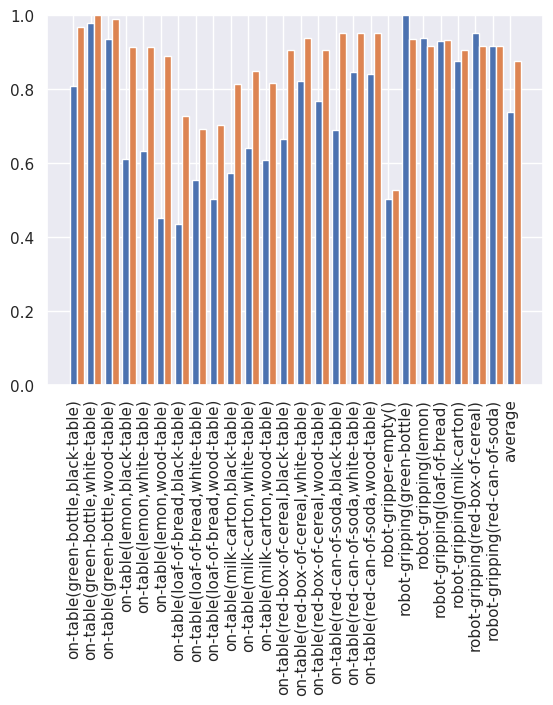

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

m = 'llama-llava-iter-images'


fig, ax = plt.subplots()

width=0.4
heights1 = accuracy[m].values()
heights2 = acc_cooc[m].values()
bars = accuracy[m].keys()
y_pos = range(len(bars))
y_pos2 = [p + width for p in y_pos]
ax.bar(y_pos, heights1, width=width, label='acc')
ax.bar(y_pos2, heights2, width=width, label='cooc')
ax.set_ylim((0, 1))

# Rotation of the bars names
ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90);

In [18]:
acc_cooc['average']

KeyError: 'average'

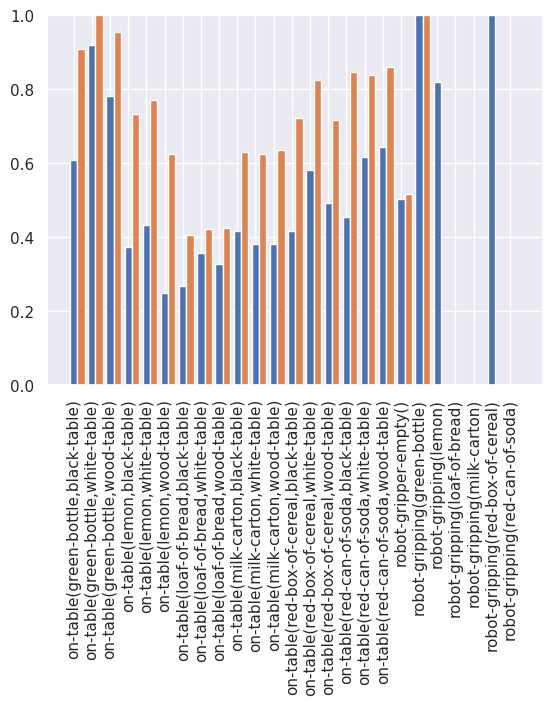

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

m = 'llama-llava-iter-images'

fig, ax = plt.subplots()

width=0.4
heights1 = prec[m].values()
heights2 = prec_cooc[m].values()
bars = prec[m].keys()
y_pos = range(len(bars))
y_pos2 = [p + width for p in y_pos]
ax.bar(y_pos, heights1, width=width, label='acc')
ax.bar(y_pos2, heights2, width=width, label='cooc')
ax.set_ylim((0, 1))

# Rotation of the bars names
ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90);

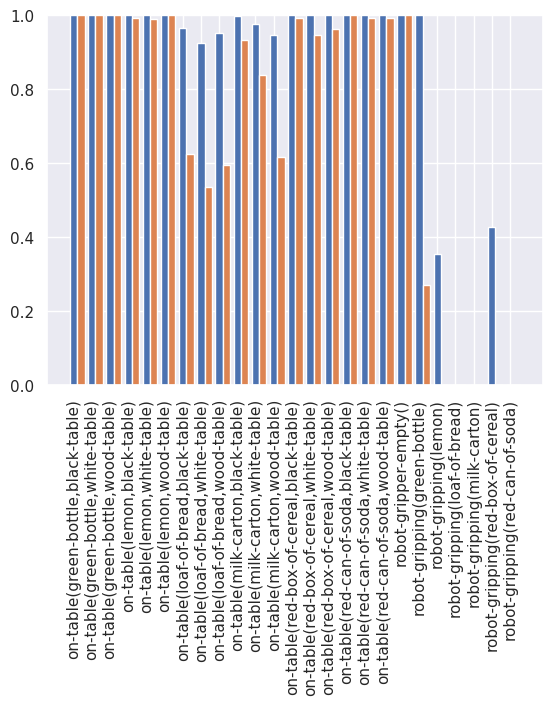

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

m = 'llama-llava-iter-images'

fig, ax = plt.subplots()

width=0.4
heights1 = rec[m].values()
heights2 = rec_cooc[m].values()
bars = prec[m].keys()
y_pos = range(len(bars))
y_pos2 = [p + width for p in y_pos]
ax.bar(y_pos, heights1, width=width, label='acc')
ax.bar(y_pos2, heights2, width=width, label='cooc')
ax.set_ylim((0, 1))

# Rotation of the bars names
ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90);

In [ ]:
len(heights2)

In [ ]:
(
    accuracy_home,
    average_precision_home,
    precision_home,
    recall_home,
    thresholds_home,
    npv_no_home,
    specificity_home,
    fpr_home,
    tpr_home,
    auc_home
) = collect_metrics_all_models(gts, preds)

In [ ]:
accuracy['home-default'] = accuracy_home['default-llama-llava']
average_precision['home-default'] = average_precision_home['default-llama-llava']

accuracy['home-iter'] = accuracy_home['llama-llava-iter-images']
average_precision['home-iter'] = average_precision_home['llama-llava-iter-images']

accuracy['home-iter72'] = accuracy_home['llama-llava-iter-images-72B']
average_precision['home-iter72'] = average_precision_home['llama-llava-iter-images-72B']

accuracy['home-iter-milk'] = accuracy_home['llama-llava-iter-images-with-milk-inst']
average_precision['home-iter-milk'] = average_precision_home['llama-llava-iter-images-with-milk-inst']

accuracy['home-iter-milk72'] = accuracy_home['llama-llava-iter-images-with-milk-inst-72B']
average_precision['home-iter-milk72'] = average_precision_home['llama-llava-iter-images-with-milk-inst-72B']

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

def plot_compare_2_models(metric, m1, m2, l1, l2, title, xlabel, ylabel, color1, color2, ax = None):
    if ax is None:
        fig, ax = plt.subplots()
    
    width=0.4
    heights1 = metric[m1].values()
    heights2 = metric[m2].values()
    bars = metric[m1].keys()
    y_pos = range(len(bars))
    y_pos2 = [p + width for p in y_pos]
    ax.bar(y_pos, heights1, width=width, label=l1, color=color1)
    ax.bar(y_pos2, heights2, width=width, label=l2, color=color2)
    ax.set_ylim((0, 1))
    
    # Rotation of the bars names
    ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    

In [ ]:
import pandas as pd

df = pd.DataFrame.from_dict({k: v for k, v in average_precision.items() if k.startswith('home')})

In [ ]:
df.plot.bar(figsize=(22, 5))
plt.legend(loc='upper left', ncol=5, bbox_to_anchor=[0.1, 1.01])

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))

width = 0.15

h1 = accuracy['default-llama-llava'].values()
h2 = accuracy['llama-llava-iter-images'].values()
h3 = accuracy['llama-llava-iter-images-72B'].values()
h4 = accuracy['llama-llava-iter-images-with-milk-inst'].values()
h5 = accuracy['llama-llava-iter-images-with-milk-inst-72B'].values()

bars = accuracy['default-llama-llava'].keys()
y_pos = np.arange(len(bars))

ax.bar(y_pos, h1, width=width, label='default')
ax.bar(y_pos + width, h2, width=width, label='iter')
ax.bar(y_pos + width*2, h3, width=width, label='iter72')
ax.bar(y_pos + width*3, h4, width=width, label='iter-milk')
ax.bar(y_pos + width*4, h5, width=width, label='iter-milk72')

ax.set_xticks(y_pos + 0.375, bars, rotation=90)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=5, bbox_to_anchor=[0.1, 1.01])

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(accuracy, 'default-llama-llava', 'llama-llava-iter-images',
                      'end action anywhere', 'end action at home', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(average_precision, 'default-llama-llava', 'llama-llava-iter-images',
                      'end action anywhere', 'end action at home pose', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      'end action anywhere', 'end action at home', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      'end action anywhere', 'end action at home pose', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'home',
                      'end action anywhere', 'end action at home', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#56ad74', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'home',
                      'end action anywhere', 'end action at home pose', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#56ad74', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'home',
#                       'end action anywhere', 'end action at home pose', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#56ad74', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      '7B model', '72B model', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#dd8453', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      '7B model', '72B model', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#dd8453', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
#                       '7B model', '72B model', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#dd8453', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different VQA Model Sizes')

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
                      '7B model', '72B model', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#dd8453', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
                      '7B model', '72B model', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#dd8453', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
#                       '7B model', '72B model', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#dd8453', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different VQA Model Sizes')

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images-72B', 'llama-llava-iter-images-with-milk-inst-72B',
                      '7B model', '72B model', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#dd8453', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images-72B', 'llama-llava-iter-images-with-milk-inst-72B',
                      '7B model', '72B model', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#dd8453', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
#                       '7B model', '72B model', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#dd8453', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different VQA Model Sizes')

In [ ]:
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'default-llama-llava',
                      '7B model', '72B model', 'Accuracy compare model sizes', 'predicate', 'prediction accuracy', '#4c72b0', '#56ad74')

In [ ]:
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'default-llama-llava',
                      '7B model', '72B model', 'Accuracy compare model sizes', 'predicate', 'prediction accuracy', '#4c72b0', '#56ad74')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()


heights = accuracy['llama-llava-iter-images'].values()
bars = accuracy['llama-llava-iter-images'].keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = average_precision['llama-llava-iter-images'].values()
bars = average_precision['llama-llava-iter-images'].keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = auc.values()
bars = auc.keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
# precision = precision['llama-llava-iter-images-72B']
# recall = recall['llama-llava-iter-images-72B']
# thresholds = thresholds['llama-llava-iter-images-72B']

for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'precisions and recall: {predicate}')
    plt.plot(thresholds[predicate], precision[predicate], label='precision')
    plt.plot(thresholds[predicate], recall[predicate], label='recall')
    plt.legend()
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'PRC: {predicate}')
    plt.plot(recall[predicate], precision[predicate])
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'npv and specificity: {predicate}')
    plt.plot(thresholds[predicate], npv[predicate], label='npv')
    plt.plot(thresholds[predicate], specificity[predicate], label='specificity')
    plt.legend()
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'NSC: {predicate}')
    plt.plot(specificity[predicate], npv[predicate])
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'ROC: {predicate}')
    plt.plot(fpr[predicate], tpr[predicate])
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.show()

In [ ]:
from semantic_state_estimator.semantic_state_estimator import SemanticEstimatorMultiImageRun
from PIL import Image
from llava.constants import DEFAULT_IMAGE_TOKEN

EXAMPLE = 'groceriesworld'
LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-7b-ov"
LLAVA_ID = "lmms-lab/llava-onevision-qwen2-72b-ov"

# additional_instructions=f"The robot's gripper is a suction gripper. If an item appears stuck to the robot end-effector, this means that the robot is currently gripping that item and that the gripper is not empty. Otherwise, the gripper is considerred empty. Below is an example of a red soda can being gripped by the robot.\n{DEFAULT_IMAGE_TOKEN}"
# additional_images = [Image.open(f'examples/{EXAMPLE}/grip-milk-full.png')]

# additional_instructions=f"{DEFAULT_IMAGE_TOKEN}\nThis is what it looks like when the robot is gripping the milk carton"
# additional_images = [Image.open(f'examples/{EXAMPLE}/grip-milk-full.png')]

# additional_instructions=f"{DEFAULT_IMAGE_TOKEN}\nThis is what it looks like when the robot is gripping the loaf of bread"
# additional_images = [Image.open(f'examples/{EXAMPLE}/grip-bread.png')]

# additional_instructions=f"The robot's gripper is a suction gripper. If an item appears stuck to the robot end-effector, this means that the robot is currently gripping that item and that the gripper is not empty.\n{DEFAULT_IMAGE_TOKEN}\nThis is what it looks like when the robot gripper is empty."
# additional_images = [Image.open(f'examples/{EXAMPLE}/gripper-empty.png')]

# additional_instructions=f"{DEFAULT_IMAGE_TOKEN}\nThis is the milk carton"
# additional_images = [Image.open(f'examples/{EXAMPLE}/milk-carton.png')]

# additional_instructions="""The user will show you images of a simulated robot and ask questions about the state of the environment.
# The robot's gripper is a suction gripper. If an item appears stuck to the robot end-effector, this means that the robot is currently gripping that item and that the gripper is not empty.\n{DEFAULT_IMAGE_TOKEN}\nThis is what it looks like when the robot gripper is empty.
# The milk carton is a clean white rectangular box with a triangular top.
# The loaf of bread looks like a brown box with one side curved.
# """

additional_instructions="""The user will show you images of a simulated robot and ask questions about the state of the environment.
Possible items that can be gripped by the robot are: milk carton, bread, green bottle, lemon, cereal box, soda can.
The robot's gripper is a pinch gripper. If an item appears between its pincers, this means that the robot is currently gripping that item and that the gripper is not empty. Otherwise, the gripper is considered empty.
"""


se = SemanticEstimatorMultiImageRun(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id=LLAVA_ID,
    additional_instructions=addtional_instructions,
    additional_images=additional_images
)

In [ ]:
additional_instructions="""The user will show you images of a simulated robot and ask questions about the state of the environment.
Possible items that can be gripped by the robot are: milk carton, bread, green bottle, lemon, cereal box, soda can.
The robot's gripper is a pinch gripper. If an item appears between its pincers, this means that the robot is currently gripping that item and that the gripper is not empty. Otherwise, the gripper is considered empty.
The milk carton is a clean white rectangular box with a triangular top. When the robot is holding the milk carton it looks like there is a white rectangular object being pinched by the robot's gripper.
The loaf of bread looks like a small brown cube with one side curved. When the robot is holding the loaf of bread it looks like the robot is gripping a dark brown box.
"""

In [ ]:
se.vqa_model.system_prompt = f'\nAdditional Instructions and clarifications:\n{addtional_instructions}'

In [ ]:
se.vqa_model.system_prompt

In [ ]:
from semantic_state_estimator.utils.misc import remove_from_gpu_memory
se.vqa_model.clear_system_cache()
remove_from_gpu_memory(se)

In [ ]:
se.vqa_model.clear_system_cache()

In [ ]:
# PREDICATE = 'on-table(milk-carton,white-table)'
# PREDICATE = 'robot-gripper-empty()'
# PREDICATE = 'robot-gripping(milk-carton)'
# PREDICATE = 'robot-gripping(loaf-of-bread)'
# PREDICATE = 'on-table(loaf-of-bread,black-table)'
PREDICATE = 'robot-gripping(red-can-of-soda)'
# PREDICATE = 'on-top-of(red_block,yellow_block)'

dps = []
for dp_name in gts.keys():
# for dp_name in preds['llama-llava-iter-images'].keys():
    # if gts[dp_name][PREDICATE] != (preds['llama-llava-iter-images'][dp_name][PREDICATE] > 0.5):
    if gts[dp_name][PREDICATE] == True:
        dps.append(dp_name)
len(dps)

In [ ]:
from PIL import Image

dp_name = np.random.choice(dps)

img = Image.fromarray(
    all_renders[dp_name]['frontview']
)
print(gts[dp_name][PREDICATE])
img

In [ ]:
# se.estimate_state_par([
#     Image.fromarray(img_arr)
#     for img_arr in all_renders[dp_name].values()
# ], batch_size=16)
se.estimate_state([
    Image.fromarray(all_renders[dp_name]['frontview'])
])

In [ ]:
from tqdm.auto import tqdm
imgs = [
    Image.fromarray(img_arr)
    for img_arr in all_renders[dp_name].values()
]

np.mean([
    se.logits_to_yes_no_probs(se.vqa_model([img], ["Is the robot currently holding the bread?"])[:, -1].float()).item()
    for img in tqdm(imgs)
])

In [ ]:
se.vqa_model.generate([imgs[0]], "what colors are the tables?")

In [ ]:
dp_name

In [ ]:
'hello'.split('l')

In [ ]:
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR
)

DATA_DIR = 'examples/groceriesworld/data_dir'
seeds = os.listdir(os.path.join(DATA_DIR, PROCESSED_DIR))
# seeds.remove('llama-llava-iter-images-72B')

all_renders = {}
gts = {}
preds = {seed: {} for seed in seeds}
for renders_file in tqdm(glob.glob(os.path.join(DATA_DIR, PROCESSED_DIR, 'llama-llava-iter-images-72B', '*.json'))):
    dp_name = os.path.splitext(os.path.basename(renders_file))[0]
    
    all_renders[dp_name] = np.load(os.path.join(DATA_DIR, RENDERS_DIR, dp_name + '.npz'))
    
    with open(os.path.join(DATA_DIR, TRUE_STATES_DIR, dp_name + '.json'), 'r') as f:
        gts[dp_name] = json.load(f)

    for seed in seeds:
        with open(os.path.join(DATA_DIR, PROCESSED_DIR, str(seed), dp_name + '.json'), 'r') as f:
            preds[seed][dp_name] = json.load(f)